# Bitcoin Forecast Freeze and Validation

## Role
Formal boundary between expensive generation and inexpensive analysis.

## Inputs
All frozen Bitcoin point vectors and the canonical target.

## Outputs
Validation PASS table; no forecast writes.

## Depends On
01–06.

## Authoritative Status
AUTHORITATIVE VALIDATION GATE

## What This Notebook Does Not Do
It does not train, regenerate, promote, or overwrite forecasts.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.bitcoin_pipeline import *
RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False


In [2]:
# Load the canonical split and frozen forecast matrix.
_, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)
validated = load_validated_forecasts(ROOT)

# Run the existing freeze-boundary integrity checks.
checks = {
    '1,061 rows and 10 data columns after Timestamp index': validated.shape == (1061, 10),
    'Exact timestamps': validated.index.equals(test.index),
    'Actual identity': np.allclose(validated.Actual, test),
    'Finite values': np.isfinite(validated.to_numpy()).all(),
    'Unique sorted index': validated.index.is_unique and validated.index.is_monotonic_increasing,
}
assert all(checks.values())

# Display the unchanged validation results.
pd.Series(checks, name='Passed')

1,061 rows and 10 data columns after Timestamp index    True
Exact timestamps                                        True
Actual identity                                         True
Finite values                                           True
Unique sorted index                                     True
Name: Passed, dtype: bool

## Complete frozen-model comparison

All metrics below are recomputed only from the validated forecast matrix and canonical training series, then sorted by RMSE.

In [3]:
import matplotlib.pyplot as plt

# Reconstruct the full ten-model mapping from frozen vectors.
forecasts = forecast_series(validated, target)
all_model_metrics = metric_table(validated.Actual, forecasts, train).sort_values('RMSE')

# Display all requested point metrics side by side.
all_model_metrics[['MAE', 'RMSE', 'MAPE', 'sMAPE', 'MASE']]

,MAE,RMSE,MAPE,sMAPE,MASE
Model,,,,,
Naive,1290.353242,1853.624774,1.742747,1.744142,4.575633
Simple Exponential Smoothing — Rolling One-Step,1290.358684,1855.731424,1.742685,1.743871,4.575652
ARIMA Rolling One-Step,1299.874638,1866.302859,1.754004,1.754209,4.609396
Additive-Trend Exponential Smoothing,1308.541314,1871.702185,1.763640,1.763424,4.640128
Persistence-Enhanced Log-Return LSTM,1321.365311,1881.091190,1.783956,1.791645,4.685603
TimesFM,1349.946786,1924.199337,1.823179,1.823895,4.786953
Chronos-Bolt-Tiny,1424.025828,1994.007926,1.934509,1.928782,5.049640
Persistence-Enhanced Log-Return Transformer,2019.366342,2559.749810,2.710936,2.759271,7.160736
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208,7.835935


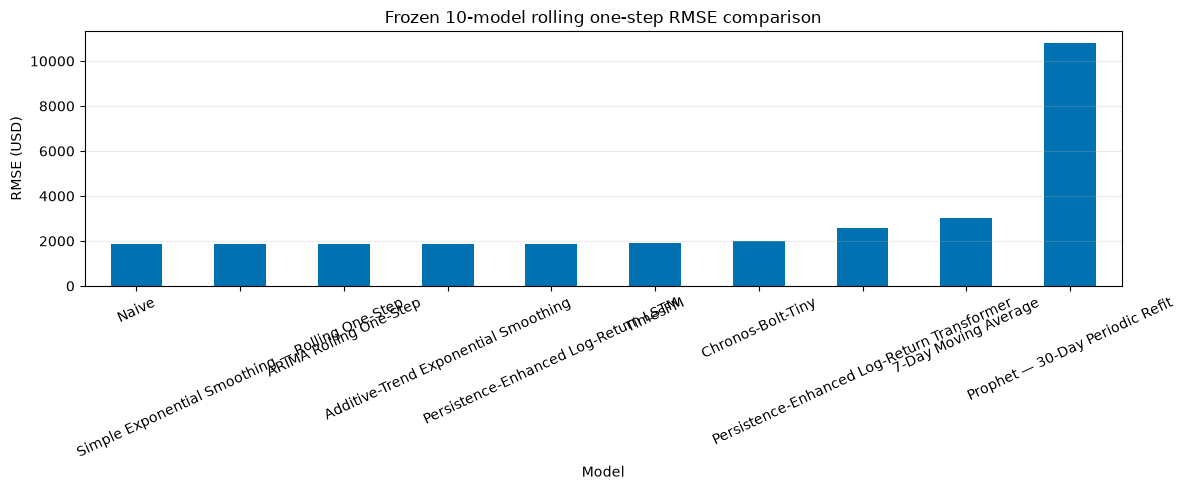

In [4]:
# Plot the exact full ten-model RMSE values shown above.
ax = all_model_metrics['RMSE'].sort_values().plot(kind='bar', figsize=(12, 5), color='#0072B2')
ax.set(title='Frozen 10-model rolling one-step RMSE comparison', xlabel='Model', ylabel='RMSE (USD)')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
ax.figure.tight_layout()
plt.show()

In [5]:
import subprocess

# Execute the repository-wide frozen-artifact verifier.
run = subprocess.run(
    [sys.executable, str(ROOT / 'src' / 'verify_research_artifacts.py')],
    capture_output=True,
    text=True,
)
print(run.stdout.splitlines()[-1])
assert run.returncode == 0

SUMMARY: 281 PASS, 0 FAIL


## Promotion controls
Generation must target `results/staging/bitcoin/<run-id>/`. `promote_staged_forecast` requires schema, timestamp, row-count, finite-value, optional hash checks, and `explicit_opt_in=True`.

## Key Findings

All ten frozen forecast vectors pass the shape, timestamp, actual-identity, finiteness, and ordering checks at the formal freeze boundary. The complete table and chart report a single fair rolling one-step comparison, with the full model set sorted by RMSE before downstream robustness, uncertainty, and inference analyses.